In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#install tensorflow
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 644.9/644.9 MB 536.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 72.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 98.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 96.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 53.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/224.5 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 4.0 MB/s eta 0:00:00


In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import time
import matplotlib.pyplot as plt

# Loading and preprocessing the Flowers dataset
def load_and_preprocess_data():
    # Load the dataset
    (train_ds, test_ds), ds_info = tfds.load(
        'tf_flowers',
        split=['train[:80%]', 'train[80%:]'],
        with_info=True,
        as_supervised=True
    )

    # Defining image size
    img_size = (64, 64)


    # Preprocessing the dataset
    def preprocess(image, label):
        image = tf.image.resize(image, img_size)
        image = tf.cast(image, tf.float32) / 255.0
        return image, label

    train_ds = train_ds.map(preprocess).shuffle(buffer_size=1000).batch(batch_size).prefetch(tf.data.experimental.AUTOTUNE)
    test_ds = test_ds.map(preprocess).batch(batch_size).prefetch(tf.data.experimental.AUTOTUNE)

    # Printing shapes of the datasets
    print(f"Training data shape: {ds_info.splits['train[:80%]'].num_examples}")
    print(f"Testing data shape: {ds_info.splits['train[80%:]'].num_examples}")

    return train_ds, test_ds, ds_info


**EXPERIMENT** **ONE**

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/tf_flowers/incomplete.IV9UF2_3.0.1/tf_flowers-train.tfrecord*...:   0%|   …

Dataset tf_flowers downloaded and prepared to /root/tensorflow_datasets/tf_flowers/3.0.1. Subsequent calls will reuse this data.
Training data shape: 2936
Testing data shape: 734
Round 1/30
Training on client 1
Training on client 2
Training on client 3
Training on client 4
Training on client 5
Training on client 6
Training on client 7
Training on client 8
Training on client 9
Training on client 10
Communication overhead for round 1: 2.6087 MB
Global model accuracy after round 1: 0.4033
Round 2/30
Training on client 1
Training on client 2
Training on client 3
Training on client 4
Training on client 5
Training on client 6
Training on client 7
Training on client 8
Training on client 9
Training on client 10
Communication overhead for round 2: 2.6087 MB
Global model accuracy after round 2: 0.4659
Round 3/30
Training on client 1
Training on client 2
Training on client 3
Training on client 4
Training on client 5
Training on client 6
Training on client 7
Training on client 8
Training on client

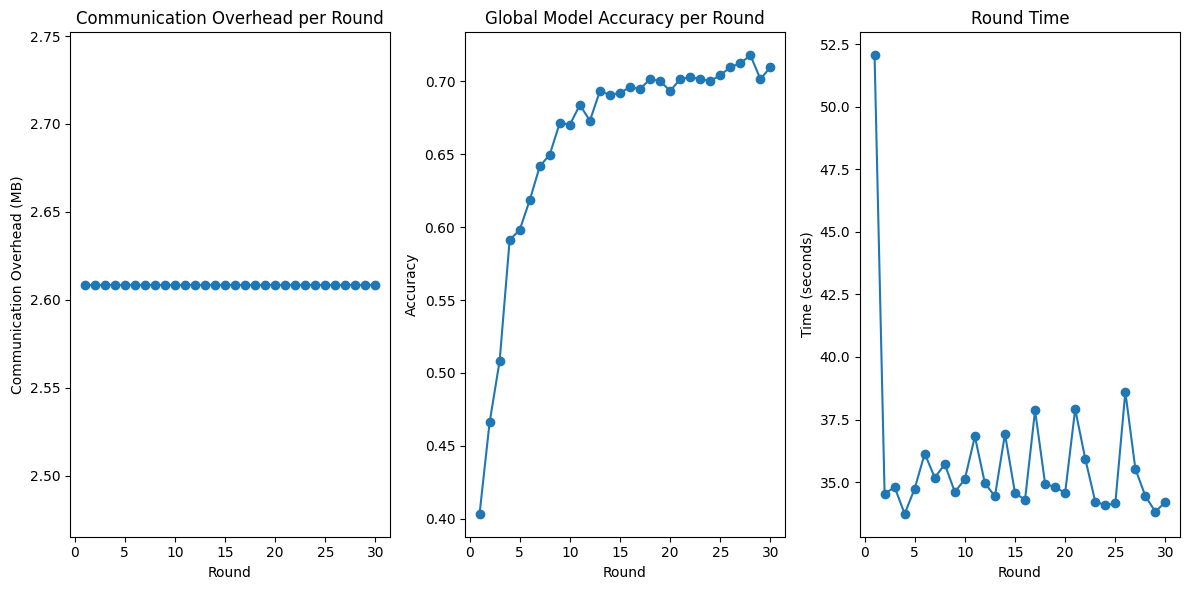

In [ ]:

# Define the global CNN model
def create_cnn_model(input_shape, num_classes):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(num_classes, activation='softmax')  # Number of classes for the Flowers dataset
    ])
    return model

# Create federated data by splitting the dataset among clients
def create_federated_data(dataset, num_clients=10):
    client_data = []
    data_per_client = len(dataset) // num_clients
    for i in range(num_clients):
        client_ds = dataset.skip(i * data_per_client).take(data_per_client)
        client_data.append(client_ds)
    return client_data

# Measure communication overhead
def measure_communication_overhead(weights):
    return sum([np.prod(w.shape) for w in weights]) * 4 / (1024 * 1024)  # in MB

# Federated learning parameters
num_clients = 10
num_rounds = 30
local_epochs = 3
accuracy_threshold = 0.70  #  accuracy threshold for convergence speed

# Load and preprocess data
train_ds, test_ds, ds_info = load_and_preprocess_data()

# Create federated data for each client
federated_train_data = create_federated_data(train_ds, num_clients)

# Create global model
input_shape = (64, 64, 3)  # Input shape for the Flowers dataset
num_classes = ds_info.features['label'].num_classes
global_model = create_cnn_model(input_shape, num_classes)
global_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Initialize variables to measure communication overhead and convergence speed
total_communication_overhead = 0
convergence_round = None
start_time = time.time()

# Lists to store metrics for visualization
communication_overheads = []
accuracies = []
round_times = []

# Federated learning loop
for round_num in range(num_rounds):
    print(f"Round {round_num + 1}/{num_rounds}")

    local_weights = []
    round_start_time = time.time()

    # Train on each client
    for client_id in range(num_clients):
        print(f"Training on client {client_id + 1}")

        # Create local model and set global weights
        local_model = create_cnn_model(input_shape, num_classes)
        local_model.set_weights(global_model.get_weights())
        local_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

        # Get client data
        client_ds = federated_train_data[client_id]

        # Train local model
        local_model.fit(client_ds, epochs=local_epochs,batch_size=32, verbose=0)

        # Collect local model weights
        local_weights.append(local_model.get_weights())

    # Federated averaging: Aggregate local weights
    averaged_weights = [np.mean([local_weights[j][i] for j in range(num_clients)], axis=0)
                        for i in range(len(local_weights[0]))]

    # Measure communication overhead
    round_communication_overhead = measure_communication_overhead(averaged_weights)
    total_communication_overhead += round_communication_overhead
    communication_overheads.append(round_communication_overhead)
    print(f"Communication overhead for round {round_num + 1}: {round_communication_overhead:.4f} MB")

    # Update global model weights
    global_model.set_weights(averaged_weights)

    # Evaluate the global model
    loss, accuracy = global_model.evaluate(test_ds, verbose=0)
    accuracies.append(accuracy)
    print(f"Global model accuracy after round {round_num + 1}: {accuracy:.4f}")

    # Check for convergence
    if convergence_round is None and accuracy >= accuracy_threshold:
        convergence_round = round_num + 1
        convergence_time = time.time() - start_time
        print(f"Convergence achieved at round {convergence_round} with accuracy {accuracy:.4f}")
        print(f"Convergence time: {convergence_time:.2f} seconds")

    # Record round time
    round_time = time.time() - round_start_time
    round_times.append(round_time)

# Evaluate the final global model
final_loss, final_accuracy = global_model.evaluate(test_ds, verbose=0)
print(f"Final global model accuracy: {final_accuracy:.4f}")

# Print total communication overhead
print(f"Total communication overhead: {total_communication_overhead:.4f} MB")

# Print convergence information if not already printed
if convergence_round is None:
    convergence_time = time.time() - start_time
    print(f"Convergence not achieved within {num_rounds} rounds.")
else:
    print(f"Convergence achieved at round {convergence_round} with accuracy {final_accuracy:.4f}")
    print(f"Convergence time: {convergence_time:.2f} seconds")

# Visualization
rounds = list(range(1, num_rounds + 1))

plt.figure(figsize=(12, 6))

# Plot communication overhead
plt.subplot(1, 3, 1)
plt.plot(rounds, communication_overheads, marker='o')
plt.title('Communication Overhead per Round')
plt.xlabel('Round')
plt.ylabel('Communication Overhead (MB)')

# Plot accuracy
plt.subplot(1, 3, 2)
plt.plot(rounds, accuracies, marker='o')
plt.title('Global Model Accuracy per Round')
plt.xlabel('Round')
plt.ylabel('Accuracy')

# Plot round times
plt.subplot(1, 3, 3)
plt.plot(rounds, round_times, marker='o')
plt.title('Round Time')
plt.xlabel('Round')
plt.ylabel('Time (seconds)')

plt.tight_layout()
plt.show()

 **EXPERIMENT TWO**

Training data shape: 2936
Testing data shape: 734
Round 1/30
Training on client 1
Training on client 2
Training on client 3
Training on client 4
Training on client 5
Training on client 6
Training on client 7
Training on client 8
Training on client 9
Training on client 10
Training on client 11
Training on client 12
Training on client 13
Training on client 14
Training on client 15
Training on client 16
Training on client 17
Training on client 18
Training on client 19
Training on client 20
Communication overhead for round 1: 2.6087 MB
Global model accuracy after round 1: 0.3447
Round 2/30
Training on client 1
Training on client 2
Training on client 3
Training on client 4
Training on client 5
Training on client 6
Training on client 7
Training on client 8
Training on client 9
Training on client 10
Training on client 11
Training on client 12
Training on client 13
Training on client 14
Training on client 15
Training on client 16
Training on client 17
Training on client 18
Training on client 1

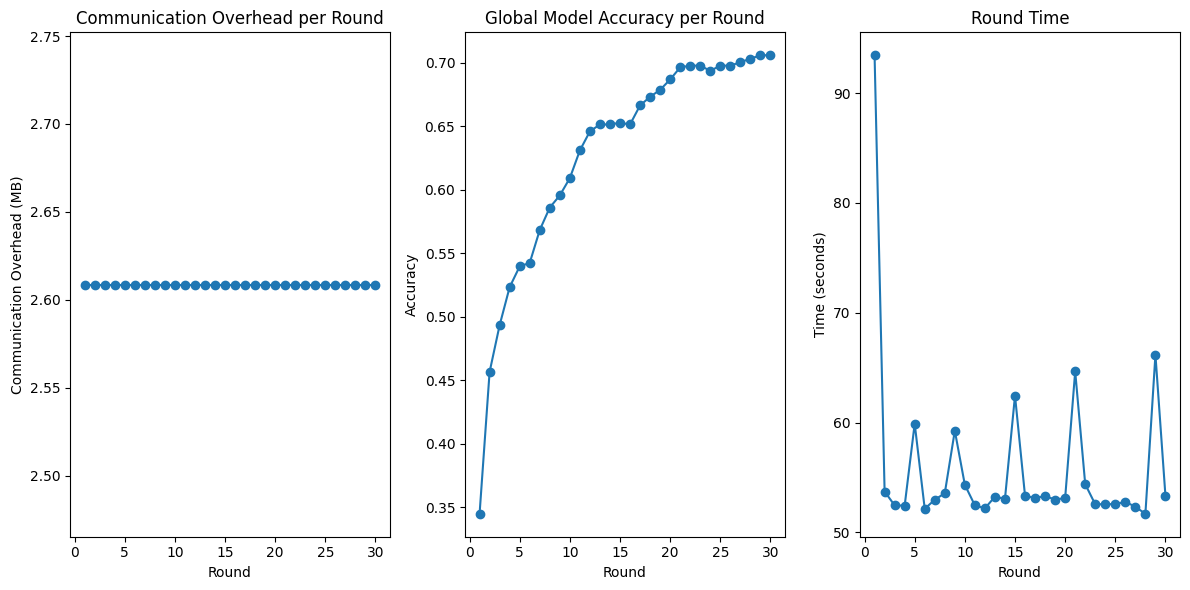

In [ ]:

# Define the global CNN model
def create_cnn_model(input_shape, num_classes):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(num_classes, activation='softmax')  # Number of classes for the Flowers dataset
    ])
    return model

# Create federated data by splitting the dataset among clients
def create_federated_data(dataset, num_clients=20):
    client_data = []
    data_per_client = len(dataset) // num_clients
    for i in range(num_clients):
        client_ds = dataset.skip(i * data_per_client).take(data_per_client)
        client_data.append(client_ds)
    return client_data

# Measure communication overhead
def measure_communication_overhead(weights):
    return sum([np.prod(w.shape) for w in weights]) * 4 / (1024 * 1024)  # in MB

# Federated learning parameters
num_clients = 20
num_rounds = 30
local_epochs = 3
accuracy_threshold = 0.70  # Define an accuracy threshold for convergence speed

# Load and preprocess data
train_ds, test_ds, ds_info = load_and_preprocess_data()

# Create federated data for each client
federated_train_data = create_federated_data(train_ds, num_clients)

# Create global model
input_shape = (64, 64, 3)  # Input shape for the Flowers dataset
num_classes = ds_info.features['label'].num_classes
global_model = create_cnn_model(input_shape, num_classes)
global_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Initialize variables to measure communication overhead and convergence speed
total_communication_overhead = 0
convergence_round = None
start_time = time.time()

# Lists to store metrics for visualization
communication_overheads = []
accuracies = []
round_times = []

# Federated learning loop
for round_num in range(num_rounds):
    print(f"Round {round_num + 1}/{num_rounds}")

    local_weights = []
    round_start_time = time.time()

    # Train on each client
    for client_id in range(num_clients):
        print(f"Training on client {client_id + 1}")

        # Create local model and set global weights
        local_model = create_cnn_model(input_shape, num_classes)
        local_model.set_weights(global_model.get_weights())
        local_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

        # Get client data
        client_ds = federated_train_data[client_id]

        # Train local model
        local_model.fit(client_ds, epochs=local_epochs,batch_size=32, verbose=0)

        # Collect local model weights
        local_weights.append(local_model.get_weights())

    # Federated averaging: Aggregate local weights
    averaged_weights = [np.mean([local_weights[j][i] for j in range(num_clients)], axis=0)
                        for i in range(len(local_weights[0]))]

    # Measure communication overhead
    round_communication_overhead = measure_communication_overhead(averaged_weights)
    total_communication_overhead += round_communication_overhead
    communication_overheads.append(round_communication_overhead)
    print(f"Communication overhead for round {round_num + 1}: {round_communication_overhead:.4f} MB")

    # Update global model weights
    global_model.set_weights(averaged_weights)

    # Evaluate the global model
    loss, accuracy = global_model.evaluate(test_ds, verbose=0)
    accuracies.append(accuracy)
    print(f"Global model accuracy after round {round_num + 1}: {accuracy:.4f}")

    # Check for convergence
    if convergence_round is None and accuracy >= accuracy_threshold:
        convergence_round = round_num + 1
        convergence_time = time.time() - start_time
        print(f"Convergence achieved at round {convergence_round} with accuracy {accuracy:.4f}")
        print(f"Convergence time: {convergence_time:.2f} seconds")

    # Record round time
    round_time = time.time() - round_start_time
    round_times.append(round_time)

# Evaluate the final global model
final_loss, final_accuracy = global_model.evaluate(test_ds, verbose=0)
print(f"Final global model accuracy: {final_accuracy:.4f}")

# Print total communication overhead
print(f"Total communication overhead: {total_communication_overhead:.4f} MB")

# Print convergence information if not already printed
if convergence_round is None:
    convergence_time = time.time() - start_time
    print(f"Convergence not achieved within {num_rounds} rounds.")
else:
    print(f"Convergence achieved at round {convergence_round} with accuracy {final_accuracy:.4f}")
    print(f"Convergence time: {convergence_time:.2f} seconds")

# Visualization
rounds = list(range(1, num_rounds + 1))

plt.figure(figsize=(12, 6))

# Plot communication overhead
plt.subplot(1, 3, 1)
plt.plot(rounds, communication_overheads, marker='o')
plt.title('Communication Overhead per Round')
plt.xlabel('Round')
plt.ylabel('Communication Overhead (MB)')

# Plot accuracy
plt.subplot(1, 3, 2)
plt.plot(rounds, accuracies, marker='o')
plt.title('Global Model Accuracy per Round')
plt.xlabel('Round')
plt.ylabel('Accuracy')

# Plot round times
plt.subplot(1, 3, 3)
plt.plot(rounds, round_times, marker='o')
plt.title('Round Time')
plt.xlabel('Round')
plt.ylabel('Time (seconds)')

plt.tight_layout()
plt.show()

**EXPERIMENT THREE**

Training data shape: 2936
Testing data shape: 734
Round 1/30
Training on client 1
Training on client 2
Training on client 3
Training on client 4
Training on client 5
Training on client 6
Training on client 7
Training on client 8
Training on client 9
Training on client 10
Training on client 11
Training on client 12
Training on client 13
Training on client 14
Training on client 15
Training on client 16
Training on client 17
Training on client 18
Training on client 19
Training on client 20
Training on client 21
Training on client 22
Training on client 23
Training on client 24
Training on client 25
Training on client 26
Training on client 27
Training on client 28
Training on client 29
Training on client 30
Communication overhead for round 1: 2.6087 MB
Global model accuracy after round 1: 0.4046
Round 2/30
Training on client 1
Training on client 2
Training on client 3
Training on client 4
Training on client 5
Training on client 6
Training on client 7
Training on client 8
Training on client 

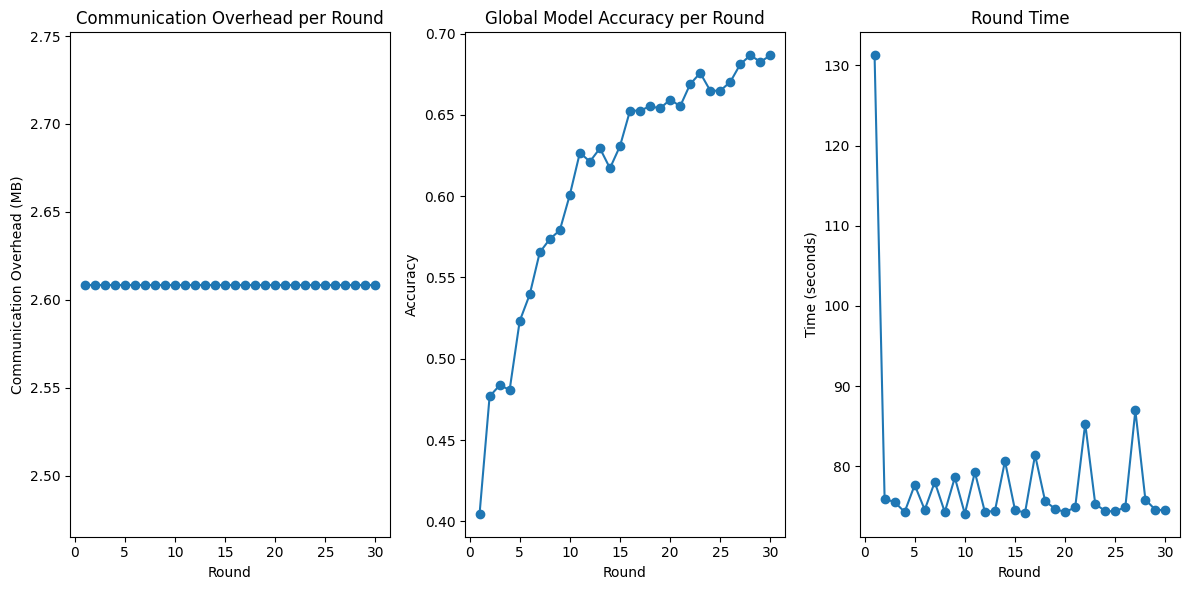

In [ ]:

# Define the global CNN model
def create_cnn_model(input_shape, num_classes):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(num_classes, activation='softmax')  # Number of classes for the Flowers dataset
    ])
    return model

# Create federated data by splitting the dataset among clients
def create_federated_data(dataset, num_clients=30):
    client_data = []
    data_per_client = len(dataset) // num_clients
    for i in range(num_clients):
        client_ds = dataset.skip(i * data_per_client).take(data_per_client)
        client_data.append(client_ds)
    return client_data

# Measure communication overhead
def measure_communication_overhead(weights):
    return sum([np.prod(w.shape) for w in weights]) * 4 / (1024 * 1024)  # in MB

# Federated learning parameters
num_clients = 30
num_rounds = 30
local_epochs = 3
accuracy_threshold = 0.70  # Define an accuracy threshold for convergence speed

# Load and preprocess data
train_ds, test_ds, ds_info = load_and_preprocess_data()

# Create federated data for each client
federated_train_data = create_federated_data(train_ds, num_clients)

# Create global model
input_shape = (64, 64, 3)  # Input shape for the Flowers dataset
num_classes = ds_info.features['label'].num_classes
global_model = create_cnn_model(input_shape, num_classes)
global_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Initialize variables to measure communication overhead and convergence speed
total_communication_overhead = 0
convergence_round = None
start_time = time.time()

# Lists to store metrics for visualization
communication_overheads = []
accuracies = []
round_times = []

# Federated learning loop
for round_num in range(num_rounds):
    print(f"Round {round_num + 1}/{num_rounds}")

    local_weights = []
    round_start_time = time.time()

    # Train on each client
    for client_id in range(num_clients):
        print(f"Training on client {client_id + 1}")

        # Create local model and set global weights
        local_model = create_cnn_model(input_shape, num_classes)
        local_model.set_weights(global_model.get_weights())
        local_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

        # Get client data
        client_ds = federated_train_data[client_id]

        # Train local model
        local_model.fit(client_ds, epochs=local_epochs,batch_size=32, verbose=0)

        # Collect local model weights
        local_weights.append(local_model.get_weights())

    # Federated averaging: Aggregate local weights
    averaged_weights = [np.mean([local_weights[j][i] for j in range(num_clients)], axis=0)
                        for i in range(len(local_weights[0]))]

    # Measure communication overhead
    round_communication_overhead = measure_communication_overhead(averaged_weights)
    total_communication_overhead += round_communication_overhead
    communication_overheads.append(round_communication_overhead)
    print(f"Communication overhead for round {round_num + 1}: {round_communication_overhead:.4f} MB")

    # Update global model weights
    global_model.set_weights(averaged_weights)

    # Evaluate the global model
    loss, accuracy = global_model.evaluate(test_ds, verbose=0)
    accuracies.append(accuracy)
    print(f"Global model accuracy after round {round_num + 1}: {accuracy:.4f}")

    # Check for convergence
    if convergence_round is None and accuracy >= accuracy_threshold:
        convergence_round = round_num + 1
        convergence_time = time.time() - start_time
        print(f"Convergence achieved at round {convergence_round} with accuracy {accuracy:.4f}")
        print(f"Convergence time: {convergence_time:.2f} seconds")

    # Record round time
    round_time = time.time() - round_start_time
    round_times.append(round_time)

# Evaluate the final global model
final_loss, final_accuracy = global_model.evaluate(test_ds, verbose=0)
print(f"Final global model accuracy: {final_accuracy:.4f}")

# Print total communication overhead
print(f"Total communication overhead: {total_communication_overhead:.4f} MB")

# Print convergence information if not already printed
if convergence_round is None:
    convergence_time = time.time() - start_time
    print(f"Convergence not achieved within {num_rounds} rounds.")
else:
    print(f"Convergence achieved at round {convergence_round} with accuracy {final_accuracy:.4f}")
    print(f"Convergence time: {convergence_time:.2f} seconds")

# Visualization
rounds = list(range(1, num_rounds + 1))

plt.figure(figsize=(12, 6))

# Plot communication overhead
plt.subplot(1, 3, 1)
plt.plot(rounds, communication_overheads, marker='o')
plt.title('Communication Overhead per Round')
plt.xlabel('Round')
plt.ylabel('Communication Overhead (MB)')

# Plot accuracy
plt.subplot(1, 3, 2)
plt.plot(rounds, accuracies, marker='o')
plt.title('Global Model Accuracy per Round')
plt.xlabel('Round')
plt.ylabel('Accuracy')

# Plot round times
plt.subplot(1, 3, 3)
plt.plot(rounds, round_times, marker='o')
plt.title('Round Time')
plt.xlabel('Round')
plt.ylabel('Time (seconds)')

plt.tight_layout()
plt.show()

**EXPERIMENT FOUR**

Training data shape: 2936
Testing data shape: 734
Round 1/30
Training on client 1
Training on client 2
Training on client 3
Training on client 4
Training on client 5
Training on client 6
Training on client 7
Training on client 8
Training on client 9
Training on client 10
Training on client 11
Training on client 12
Training on client 13
Training on client 14
Training on client 15
Training on client 16
Training on client 17
Training on client 18
Training on client 19
Training on client 20
Training on client 21
Training on client 22
Training on client 23
Training on client 24
Training on client 25
Training on client 26
Training on client 27
Training on client 28
Training on client 29
Training on client 30
Training on client 31
Training on client 32
Training on client 33
Training on client 34
Training on client 35
Training on client 36
Training on client 37
Training on client 38
Training on client 39
Training on client 40
Communication overhead for round 1: 2.6087 MB
Global model accuracy 

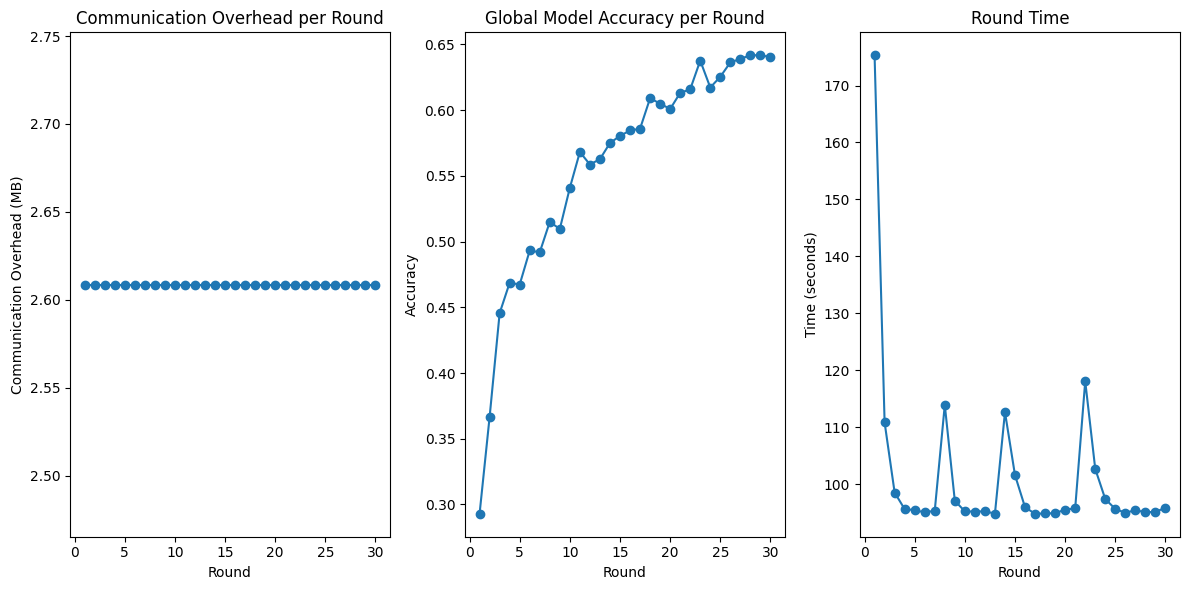

In [ ]:

# Define the global CNN model
def create_cnn_model(input_shape, num_classes):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(num_classes, activation='softmax')  # Number of classes for the Flowers dataset
    ])
    return model

# Create federated data by splitting the dataset among clients
def create_federated_data(dataset, num_clients=40):
    client_data = []
    data_per_client = len(dataset) // num_clients
    for i in range(num_clients):
        client_ds = dataset.skip(i * data_per_client).take(data_per_client)
        client_data.append(client_ds)
    return client_data

# Measure communication overhead
def measure_communication_overhead(weights):
    return sum([np.prod(w.shape) for w in weights]) * 4 / (1024 * 1024)  # in MB

# Federated learning parameters
num_clients =40
num_rounds = 30
local_epochs = 3
accuracy_threshold = 0.70  # Define an accuracy threshold for convergence speed

# Load and preprocess data
train_ds, test_ds, ds_info = load_and_preprocess_data()

# Create federated data for each client
federated_train_data = create_federated_data(train_ds, num_clients)

# Create global model
input_shape = (64, 64, 3)  # Input shape for the Flowers dataset
num_classes = ds_info.features['label'].num_classes
global_model = create_cnn_model(input_shape, num_classes)
global_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Initialize variables to measure communication overhead and convergence speed
total_communication_overhead = 0
convergence_round = None
start_time = time.time()

# Lists to store metrics for visualization
communication_overheads = []
accuracies = []
round_times = []

# Federated learning loop
for round_num in range(num_rounds):
    print(f"Round {round_num + 1}/{num_rounds}")

    local_weights = []
    round_start_time = time.time()

    # Train on each client
    for client_id in range(num_clients):
        print(f"Training on client {client_id + 1}")

        # Create local model and set global weights
        local_model = create_cnn_model(input_shape, num_classes)
        local_model.set_weights(global_model.get_weights())
        local_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

        # Get client data
        client_ds = federated_train_data[client_id]

        # Train local model
        local_model.fit(client_ds, epochs=local_epochs,batch_size=32, verbose=0)

        # Collect local model weights
        local_weights.append(local_model.get_weights())

    # Federated averaging: Aggregate local weights
    averaged_weights = [np.mean([local_weights[j][i] for j in range(num_clients)], axis=0)
                        for i in range(len(local_weights[0]))]

    # Measure communication overhead
    round_communication_overhead = measure_communication_overhead(averaged_weights)
    total_communication_overhead += round_communication_overhead
    communication_overheads.append(round_communication_overhead)
    print(f"Communication overhead for round {round_num + 1}: {round_communication_overhead:.4f} MB")

    # Update global model weights
    global_model.set_weights(averaged_weights)

    # Evaluate the global model
    loss, accuracy = global_model.evaluate(test_ds, verbose=0)
    accuracies.append(accuracy)
    print(f"Global model accuracy after round {round_num + 1}: {accuracy:.4f}")

    # Check for convergence
    if convergence_round is None and accuracy >= accuracy_threshold:
        convergence_round = round_num + 1
        convergence_time = time.time() - start_time
        print(f"Convergence achieved at round {convergence_round} with accuracy {accuracy:.4f}")
        print(f"Convergence time: {convergence_time:.2f} seconds")

    # Record round time
    round_time = time.time() - round_start_time
    round_times.append(round_time)

# Evaluate the final global model
final_loss, final_accuracy = global_model.evaluate(test_ds, verbose=0)
print(f"Final global model accuracy: {final_accuracy:.4f}")

# Print total communication overhead
print(f"Total communication overhead: {total_communication_overhead:.4f} MB")

# Print convergence information if not already printed
if convergence_round is None:
    convergence_time = time.time() - start_time
    print(f"Convergence not achieved within {num_rounds} rounds.")
else:
    print(f"Convergence achieved at round {convergence_round} with accuracy {final_accuracy:.4f}")
    print(f"Convergence time: {convergence_time:.2f} seconds")

# Visualization
rounds = list(range(1, num_rounds + 1))

plt.figure(figsize=(12, 6))

# Plot communication overhead
plt.subplot(1, 3, 1)
plt.plot(rounds, communication_overheads, marker='o')
plt.title('Communication Overhead per Round')
plt.xlabel('Round')
plt.ylabel('Communication Overhead (MB)')

# Plot accuracy
plt.subplot(1, 3, 2)
plt.plot(rounds, accuracies, marker='o')
plt.title('Global Model Accuracy per Round')
plt.xlabel('Round')
plt.ylabel('Accuracy')

# Plot round times
plt.subplot(1, 3, 3)
plt.plot(rounds, round_times, marker='o')
plt.title('Round Time')
plt.xlabel('Round')
plt.ylabel('Time (seconds)')

plt.tight_layout()
plt.show()

**EXPERIMENT FIVE**

Training data shape: 2936
Testing data shape: 734
Round 1/30
Training on client 1
Training on client 2
Training on client 3
Training on client 4
Training on client 5


Training on client 6


Training on client 7
Training on client 8
Training on client 9
Training on client 10
Training on client 11
Training on client 12
Training on client 13
Training on client 14
Training on client 15
Training on client 16
Training on client 17
Training on client 18
Training on client 19
Training on client 20
Training on client 21
Training on client 22
Training on client 23
Training on client 24
Training on client 25
Training on client 26
Training on client 27
Training on client 28
Training on client 29
Training on client 30
Training on client 31
Training on client 32
Training on client 33
Training on client 34
Training on client 35
Training on client 36
Training on client 37
Training on client 38
Training on client 39
Training on client 40
Training on client 41
Training on client 42
Training on client 43
Training on client 44
Training on client 45
Training on client 46
Training on client 47
Training on client 48
Training on client 49
Training on client 50
Communication overhead for round 1:

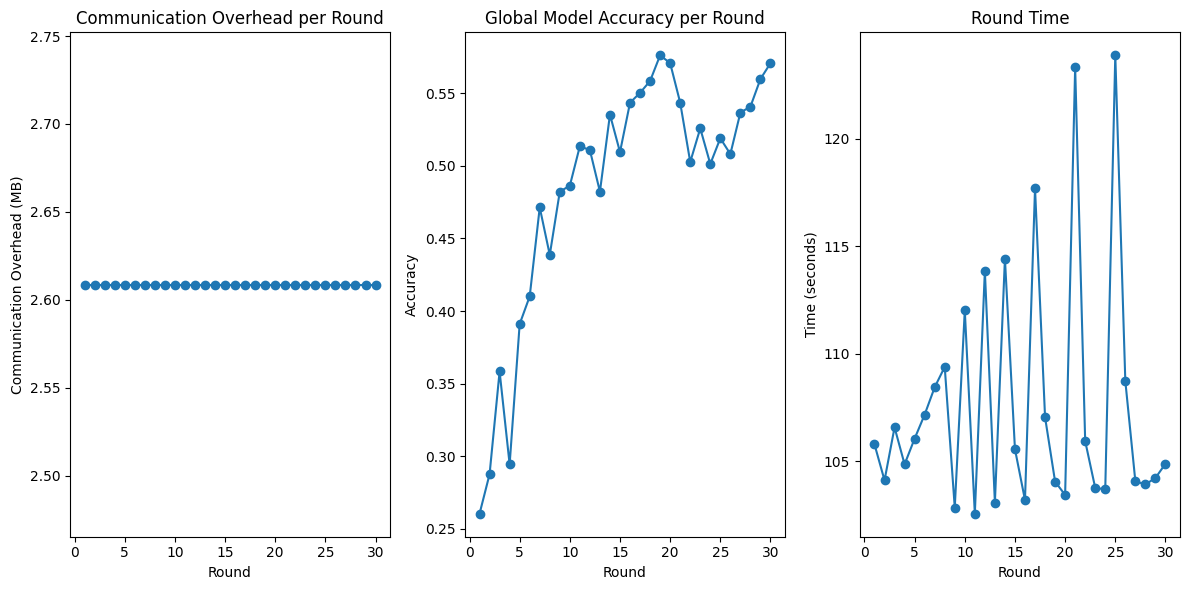

In [ ]:

# Define the global CNN model
def create_cnn_model(input_shape, num_classes):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(num_classes, activation='softmax')  # Number of classes for the Flowers dataset
    ])
    return model

# Create federated data by splitting the dataset among clients
def create_federated_data(dataset, num_clients=50):
    client_data = []
    data_per_client = len(dataset) // num_clients
    for i in range(num_clients):
        client_ds = dataset.skip(i * data_per_client).take(data_per_client)
        client_data.append(client_ds)
    return client_data

# Measure communication overhead
def measure_communication_overhead(weights):
    return sum([np.prod(w.shape) for w in weights]) * 4 / (1024 * 1024)  # in MB

# Federated learning parameters
num_clients =50
num_rounds = 30
local_epochs = 3
accuracy_threshold = 0.70  # Define an accuracy threshold for convergence speed

# Load and preprocess data
train_ds, test_ds, ds_info = load_and_preprocess_data()

# Create federated data for each client
federated_train_data = create_federated_data(train_ds, num_clients)

# Create global model
input_shape = (64, 64, 3)  # Input shape for the Flowers dataset
num_classes = ds_info.features['label'].num_classes
global_model = create_cnn_model(input_shape, num_classes)
global_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Initialize variables to measure communication overhead and convergence speed
total_communication_overhead = 0
convergence_round = None
start_time = time.time()

# Lists to store metrics for visualization
communication_overheads = []
accuracies = []
round_times = []

# Federated learning loop
for round_num in range(num_rounds):
    print(f"Round {round_num + 1}/{num_rounds}")

    local_weights = []
    round_start_time = time.time()

    # Train on each client
    for client_id in range(num_clients):
        print(f"Training on client {client_id + 1}")

        # Create local model and set global weights
        local_model = create_cnn_model(input_shape, num_classes)
        local_model.set_weights(global_model.get_weights())
        local_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

        # Get client data
        client_ds = federated_train_data[client_id]

        # Train local model
        local_model.fit(client_ds, epochs=local_epochs,batch_size=32,  verbose=0)

        # Collect local model weights
        local_weights.append(local_model.get_weights())

    # Federated averaging: Aggregate local weights
    averaged_weights = [np.mean([local_weights[j][i] for j in range(num_clients)], axis=0)
                        for i in range(len(local_weights[0]))]

    # Measure communication overhead
    round_communication_overhead = measure_communication_overhead(averaged_weights)
    total_communication_overhead += round_communication_overhead
    communication_overheads.append(round_communication_overhead)
    print(f"Communication overhead for round {round_num + 1}: {round_communication_overhead:.4f} MB")

    # Update global model weights
    global_model.set_weights(averaged_weights)

    # Evaluate the global model
    loss, accuracy = global_model.evaluate(test_ds, verbose=0)
    accuracies.append(accuracy)
    print(f"Global model accuracy after round {round_num + 1}: {accuracy:.4f}")

    # Check for convergence
    if convergence_round is None and accuracy >= accuracy_threshold:
        convergence_round = round_num + 1
        convergence_time = time.time() - start_time
        print(f"Convergence achieved at round {convergence_round} with accuracy {accuracy:.4f}")
        print(f"Convergence time: {convergence_time:.2f} seconds")

    # Record round time
    round_time = time.time() - round_start_time
    round_times.append(round_time)

# Evaluate the final global model
final_loss, final_accuracy = global_model.evaluate(test_ds, verbose=0)
print(f"Final global model accuracy: {final_accuracy:.4f}")

# Print total communication overhead
print(f"Total communication overhead: {total_communication_overhead:.4f} MB")

# Print convergence information if not already printed
if convergence_round is None:
    convergence_time = time.time() - start_time
    print(f"Convergence not achieved within {num_rounds} rounds.")
else:
    print(f"Convergence achieved at round {convergence_round} with accuracy {final_accuracy:.4f}")
    print(f"Convergence time: {convergence_time:.2f} seconds")

# Visualization
rounds = list(range(1, num_rounds + 1))

plt.figure(figsize=(12, 6))

# Plot communication overhead
plt.subplot(1, 3, 1)
plt.plot(rounds, communication_overheads, marker='o')
plt.title('Communication Overhead per Round')
plt.xlabel('Round')
plt.ylabel('Communication Overhead (MB)')

# Plot accuracy
plt.subplot(1, 3, 2)
plt.plot(rounds, accuracies, marker='o')
plt.title('Global Model Accuracy per Round')
plt.xlabel('Round')
plt.ylabel('Accuracy')

# Plot round times
plt.subplot(1, 3, 3)
plt.plot(rounds, round_times, marker='o')
plt.title('Round Time')
plt.xlabel('Round')
plt.ylabel('Time (seconds)')

plt.tight_layout()
plt.show()

**EXPERIMENT SIX**

Training data shape: 2936
Testing data shape: 734
Round 1/30
Training on client 1
Training on client 2
Training on client 3
Training on client 4
Training on client 5
Training on client 6
Training on client 7
Training on client 8
Training on client 9
Training on client 10
Training on client 11
Training on client 12
Training on client 13
Training on client 14
Training on client 15
Training on client 16
Training on client 17
Training on client 18
Training on client 19
Training on client 20
Training on client 21
Training on client 22
Training on client 23
Training on client 24
Training on client 25
Training on client 26
Training on client 27
Training on client 28
Training on client 29
Training on client 30
Training on client 31
Training on client 32
Training on client 33
Training on client 34
Training on client 35
Training on client 36
Training on client 37
Training on client 38
Training on client 39
Training on client 40
Training on client 41
Training on client 42
Training on client 43
Tr

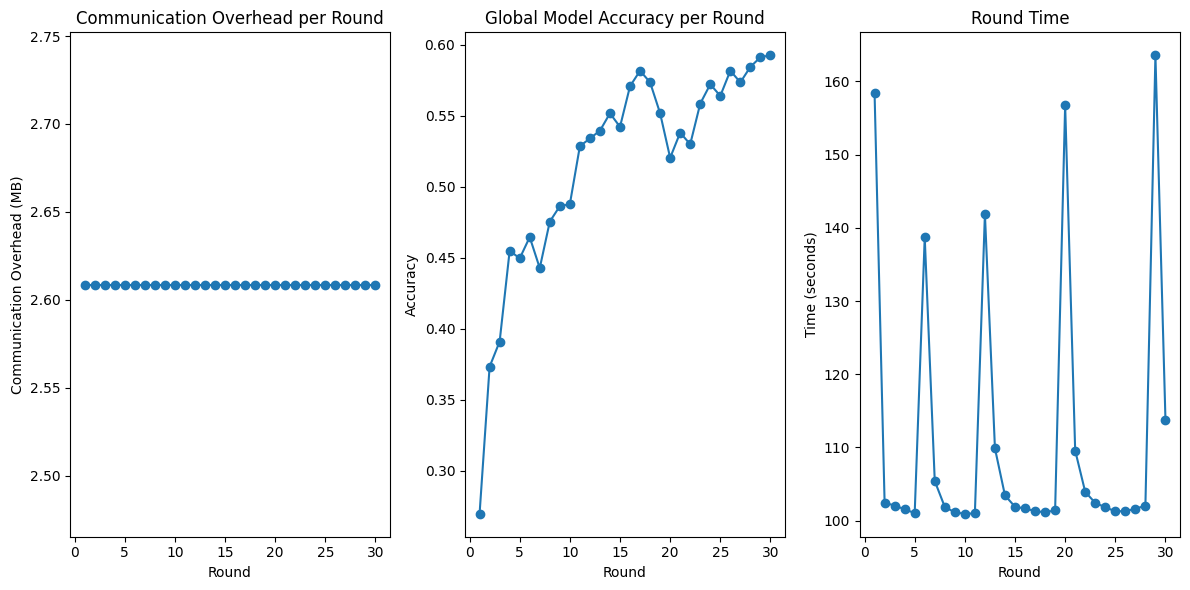

In [ ]:

# Define the global CNN model
def create_cnn_model(input_shape, num_classes):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(num_classes, activation='softmax')  # Number of classes for the Flowers dataset
    ])
    return model

# Create federated data by splitting the dataset among clients
def create_federated_data(dataset, num_clients=60):
    client_data = []
    data_per_client = len(dataset) // num_clients
    for i in range(num_clients):
        client_ds = dataset.skip(i * data_per_client).take(data_per_client)
        client_data.append(client_ds)
    return client_data

# Measure communication overhead
def measure_communication_overhead(weights):
    return sum([np.prod(w.shape) for w in weights]) * 4 / (1024 * 1024)  # in MB

# Federated learning parameters
num_clients =60
num_rounds = 30
local_epochs = 3
accuracy_threshold = 0.70  # Define an accuracy threshold for convergence speed

# Load and preprocess data
train_ds, test_ds, ds_info = load_and_preprocess_data()

# Create federated data for each client
federated_train_data = create_federated_data(train_ds, num_clients)

# Create global model
input_shape = (64, 64, 3)  # Input shape for the Flowers dataset
num_classes = ds_info.features['label'].num_classes
global_model = create_cnn_model(input_shape, num_classes)
global_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Initialize variables to measure communication overhead and convergence speed
total_communication_overhead = 0
convergence_round = None
start_time = time.time()

# Lists to store metrics for visualization
communication_overheads = []
accuracies = []
round_times = []

# Federated learning loop
for round_num in range(num_rounds):
    print(f"Round {round_num + 1}/{num_rounds}")

    local_weights = []
    round_start_time = time.time()

    # Train on each client
    for client_id in range(num_clients):
        print(f"Training on client {client_id + 1}")

        # Create local model and set global weights
        local_model = create_cnn_model(input_shape, num_classes)
        local_model.set_weights(global_model.get_weights())
        local_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

        # Get client data
        client_ds = federated_train_data[client_id]

        # Train local model
        local_model.fit(client_ds, epochs=local_epochs,batch_size=32, verbose=0)

        # Collect local model weights
        local_weights.append(local_model.get_weights())

    # Federated averaging: Aggregate local weights
    averaged_weights = [np.mean([local_weights[j][i] for j in range(num_clients)], axis=0)
                        for i in range(len(local_weights[0]))]

    # Measure communication overhead
    round_communication_overhead = measure_communication_overhead(averaged_weights)
    total_communication_overhead += round_communication_overhead
    communication_overheads.append(round_communication_overhead)
    print(f"Communication overhead for round {round_num + 1}: {round_communication_overhead:.4f} MB")

    # Update global model weights
    global_model.set_weights(averaged_weights)

    # Evaluate the global model
    loss, accuracy = global_model.evaluate(test_ds, verbose=0)
    accuracies.append(accuracy)
    print(f"Global model accuracy after round {round_num + 1}: {accuracy:.4f}")

    # Check for convergence
    if convergence_round is None and accuracy >= accuracy_threshold:
        convergence_round = round_num + 1
        convergence_time = time.time() - start_time
        print(f"Convergence achieved at round {convergence_round} with accuracy {accuracy:.4f}")
        print(f"Convergence time: {convergence_time:.2f} seconds")

    # Record round time
    round_time = time.time() - round_start_time
    round_times.append(round_time)

# Evaluate the final global model
final_loss, final_accuracy = global_model.evaluate(test_ds, verbose=0)
print(f"Final global model accuracy: {final_accuracy:.4f}")

# Print total communication overhead
print(f"Total communication overhead: {total_communication_overhead:.4f} MB")

# Print convergence information if not already printed
if convergence_round is None:
    convergence_time = time.time() - start_time
    print(f"Convergence not achieved within {num_rounds} rounds.")
else:
    print(f"Convergence achieved at round {convergence_round} with accuracy {final_accuracy:.4f}")
    print(f"Convergence time: {convergence_time:.2f} seconds")

# Visualization
rounds = list(range(1, num_rounds + 1))

plt.figure(figsize=(12, 6))

# Plot communication overhead
plt.subplot(1, 3, 1)
plt.plot(rounds, communication_overheads, marker='o')
plt.title('Communication Overhead per Round')
plt.xlabel('Round')
plt.ylabel('Communication Overhead (MB)')

# Plot accuracy
plt.subplot(1, 3, 2)
plt.plot(rounds, accuracies, marker='o')
plt.title('Global Model Accuracy per Round')
plt.xlabel('Round')
plt.ylabel('Accuracy')

# Plot round times
plt.subplot(1, 3, 3)
plt.plot(rounds, round_times, marker='o')
plt.title('Round Time')
plt.xlabel('Round')
plt.ylabel('Time (seconds)')

plt.tight_layout()
plt.show()

**EXPERIMENT SEVEN**

Training data shape: 2936
Testing data shape: 734
Round 1/30
Training on client 1
Training on client 2
Training on client 3
Training on client 4
Training on client 5
Training on client 6
Training on client 7
Training on client 8
Training on client 9
Training on client 10
Training on client 11
Training on client 12
Training on client 13
Training on client 14
Training on client 15
Training on client 16
Training on client 17
Training on client 18
Training on client 19
Training on client 20
Training on client 21
Training on client 22
Training on client 23
Training on client 24
Training on client 25
Training on client 26
Training on client 27
Training on client 28
Training on client 29
Training on client 30
Training on client 31
Training on client 32
Training on client 33
Training on client 34
Training on client 35
Training on client 36
Training on client 37
Training on client 38
Training on client 39
Training on client 40
Training on client 41
Training on client 42
Training on client 43
Tr

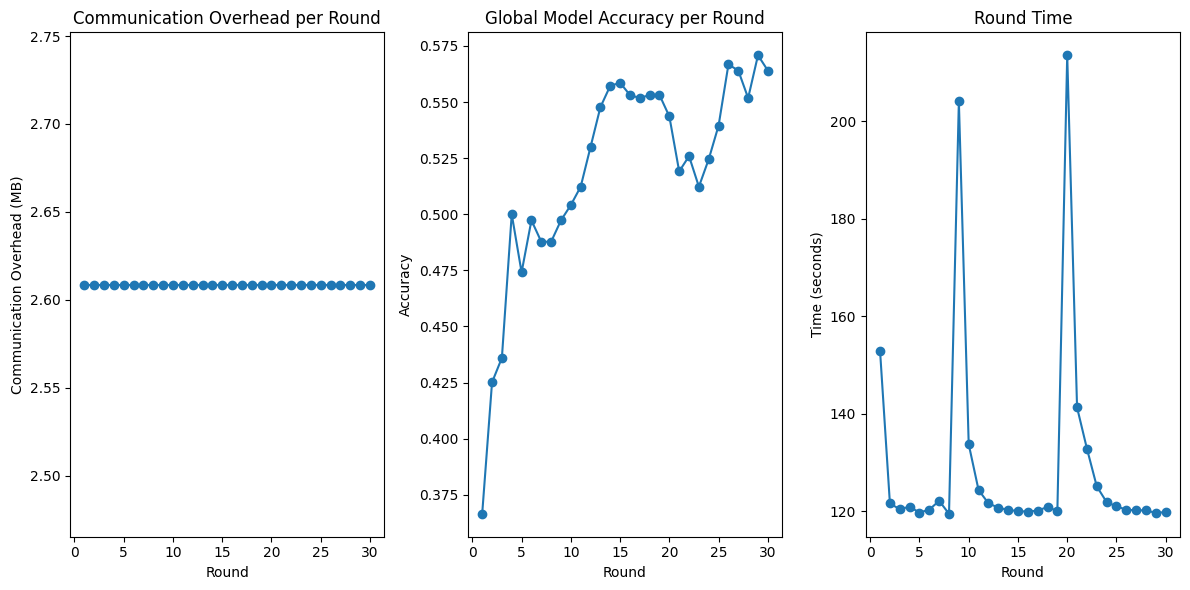

In [ ]:

# Define the global CNN model
def create_cnn_model(input_shape, num_classes):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(num_classes, activation='softmax')  # Number of classes for the Flowers dataset
    ])
    return model

# Create federated data by splitting the dataset among clients
def create_federated_data(dataset, num_clients=70):
    client_data = []
    data_per_client = len(dataset) // num_clients
    for i in range(num_clients):
        client_ds = dataset.skip(i * data_per_client).take(data_per_client)
        client_data.append(client_ds)
    return client_data

# Measure communication overhead
def measure_communication_overhead(weights):
    return sum([np.prod(w.shape) for w in weights]) * 4 / (1024 * 1024)  # in MB

# Federated learning parameters
num_clients =70
num_rounds = 30
local_epochs = 3
accuracy_threshold = 0.70  # Define an accuracy threshold for convergence speed

# Load and preprocess data
train_ds, test_ds, ds_info = load_and_preprocess_data()

# Create federated data for each client
federated_train_data = create_federated_data(train_ds, num_clients)

# Create global model
input_shape = (64, 64, 3)  # Input shape for the Flowers dataset
num_classes = ds_info.features['label'].num_classes
global_model = create_cnn_model(input_shape, num_classes)
global_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Initialize variables to measure communication overhead and convergence speed
total_communication_overhead = 0
convergence_round = None
start_time = time.time()

# Lists to store metrics for visualization
communication_overheads = []
accuracies = []
round_times = []

# Federated learning loop
for round_num in range(num_rounds):
    print(f"Round {round_num + 1}/{num_rounds}")

    local_weights = []
    round_start_time = time.time()

    # Train on each client
    for client_id in range(num_clients):
        print(f"Training on client {client_id + 1}")

        # Create local model and set global weights
        local_model = create_cnn_model(input_shape, num_classes)
        local_model.set_weights(global_model.get_weights())
        local_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

        # Get client data
        client_ds = federated_train_data[client_id]

        # Train local model
        local_model.fit(client_ds, epochs=local_epochs,batch_size=32, verbose=0)

        # Collect local model weights
        local_weights.append(local_model.get_weights())

    # Federated averaging: Aggregate local weights
    averaged_weights = [np.mean([local_weights[j][i] for j in range(num_clients)], axis=0)
                        for i in range(len(local_weights[0]))]

    # Measure communication overhead
    round_communication_overhead = measure_communication_overhead(averaged_weights)
    total_communication_overhead += round_communication_overhead
    communication_overheads.append(round_communication_overhead)
    print(f"Communication overhead for round {round_num + 1}: {round_communication_overhead:.4f} MB")

    # Update global model weights
    global_model.set_weights(averaged_weights)

    # Evaluate the global model
    loss, accuracy = global_model.evaluate(test_ds, verbose=0)
    accuracies.append(accuracy)
    print(f"Global model accuracy after round {round_num + 1}: {accuracy:.4f}")

    # Check for convergence
    if convergence_round is None and accuracy >= accuracy_threshold:
        convergence_round = round_num + 1
        convergence_time = time.time() - start_time
        print(f"Convergence achieved at round {convergence_round} with accuracy {accuracy:.4f}")
        print(f"Convergence time: {convergence_time:.2f} seconds")

    # Record round time
    round_time = time.time() - round_start_time
    round_times.append(round_time)

# Evaluate the final global model
final_loss, final_accuracy = global_model.evaluate(test_ds, verbose=0)
print(f"Final global model accuracy: {final_accuracy:.4f}")

# Print total communication overhead
print(f"Total communication overhead: {total_communication_overhead:.4f} MB")

# Print convergence information if not already printed
if convergence_round is None:
    convergence_time = time.time() - start_time
    print(f"Convergence not achieved within {num_rounds} rounds.")
else:
    print(f"Convergence achieved at round {convergence_round} with accuracy {final_accuracy:.4f}")
    print(f"Convergence time: {convergence_time:.2f} seconds")

# Visualization
rounds = list(range(1, num_rounds + 1))

plt.figure(figsize=(12, 6))

# Plot communication overhead
plt.subplot(1, 3, 1)
plt.plot(rounds, communication_overheads, marker='o')
plt.title('Communication Overhead per Round')
plt.xlabel('Round')
plt.ylabel('Communication Overhead (MB)')

# Plot accuracy
plt.subplot(1, 3, 2)
plt.plot(rounds, accuracies, marker='o')
plt.title('Global Model Accuracy per Round')
plt.xlabel('Round')
plt.ylabel('Accuracy')

# Plot round times
plt.subplot(1, 3, 3)
plt.plot(rounds, round_times, marker='o')
plt.title('Round Time')
plt.xlabel('Round')
plt.ylabel('Time (seconds)')

plt.tight_layout()
plt.show()

**EXPERIMENT EIGHT**

Training data shape: 2936
Testing data shape: 734
Round 1/30
Training on client 1
Training on client 2
Training on client 3
Training on client 4
Training on client 5
Training on client 6
Training on client 7
Training on client 8
Training on client 9
Training on client 10
Training on client 11
Training on client 12
Training on client 13
Training on client 14
Training on client 15
Training on client 16
Training on client 17
Training on client 18
Training on client 19
Training on client 20
Training on client 21
Training on client 22
Training on client 23
Training on client 24
Training on client 25
Training on client 26
Training on client 27
Training on client 28
Training on client 29
Training on client 30
Training on client 31
Training on client 32
Training on client 33
Training on client 34
Training on client 35
Training on client 36
Training on client 37
Training on client 38
Training on client 39
Training on client 40
Training on client 41
Training on client 42
Training on client 43
Tr

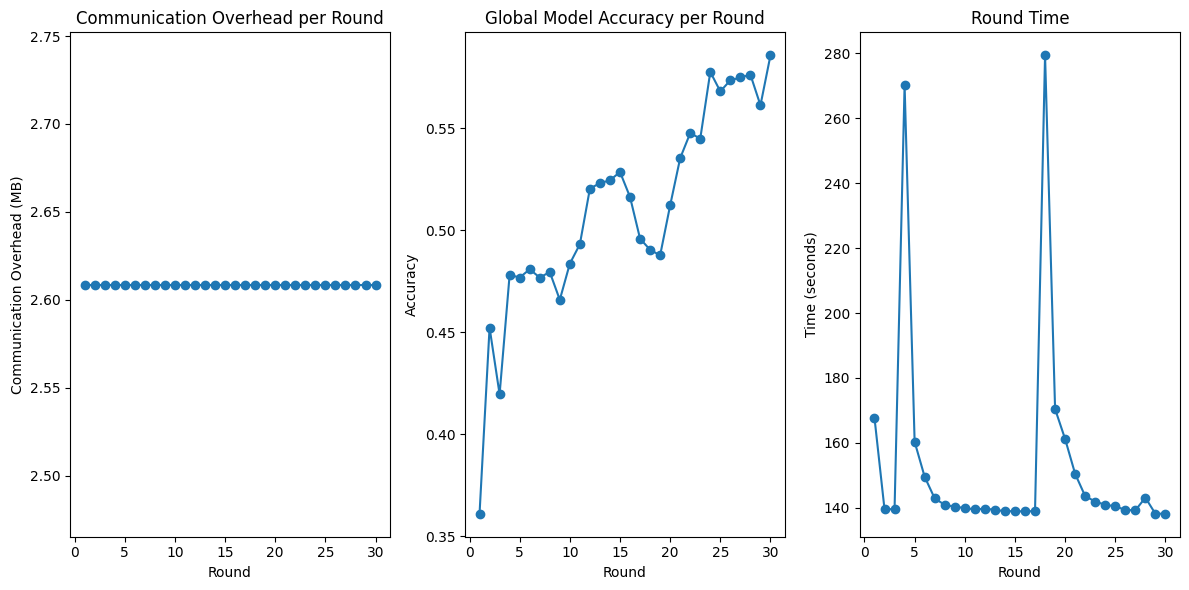

In [ ]:

# Define the global CNN model
def create_cnn_model(input_shape, num_classes):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(num_classes, activation='softmax')  # Number of classes for the Flowers dataset
    ])
    return model

# Create federated data by splitting the dataset among clients
def create_federated_data(dataset, num_clients=80):
    client_data = []
    data_per_client = len(dataset) // num_clients
    for i in range(num_clients):
        client_ds = dataset.skip(i * data_per_client).take(data_per_client)
        client_data.append(client_ds)
    return client_data

# Measure communication overhead
def measure_communication_overhead(weights):
    return sum([np.prod(w.shape) for w in weights]) * 4 / (1024 * 1024)  # in MB

# Federated learning parameters
num_clients =80
num_rounds = 30
local_epochs = 3
accuracy_threshold = 0.70  # Define an accuracy threshold for convergence speed

# Load and preprocess data
train_ds, test_ds, ds_info = load_and_preprocess_data()

# Create federated data for each client
federated_train_data = create_federated_data(train_ds, num_clients)

# Create global model
input_shape = (64, 64, 3)  # Input shape for the Flowers dataset
num_classes = ds_info.features['label'].num_classes
global_model = create_cnn_model(input_shape, num_classes)
global_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Initialize variables to measure communication overhead and convergence speed
total_communication_overhead = 0
convergence_round = None
start_time = time.time()

# Lists to store metrics for visualization
communication_overheads = []
accuracies = []
round_times = []

# Federated learning loop
for round_num in range(num_rounds):
    print(f"Round {round_num + 1}/{num_rounds}")

    local_weights = []
    round_start_time = time.time()

    # Train on each client
    for client_id in range(num_clients):
        print(f"Training on client {client_id + 1}")

        # Create local model and set global weights
        local_model = create_cnn_model(input_shape, num_classes)
        local_model.set_weights(global_model.get_weights())
        local_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

        # Get client data
        client_ds = federated_train_data[client_id]

        # Train local model
        local_model.fit(client_ds, epochs=local_epochs,batch_size=32, verbose=0)

        # Collect local model weights
        local_weights.append(local_model.get_weights())

    # Federated averaging: Aggregate local weights
    averaged_weights = [np.mean([local_weights[j][i] for j in range(num_clients)], axis=0)
                        for i in range(len(local_weights[0]))]

    # Measure communication overhead
    round_communication_overhead = measure_communication_overhead(averaged_weights)
    total_communication_overhead += round_communication_overhead
    communication_overheads.append(round_communication_overhead)
    print(f"Communication overhead for round {round_num + 1}: {round_communication_overhead:.4f} MB")

    # Update global model weights
    global_model.set_weights(averaged_weights)

    # Evaluate the global model
    loss, accuracy = global_model.evaluate(test_ds, verbose=0)
    accuracies.append(accuracy)
    print(f"Global model accuracy after round {round_num + 1}: {accuracy:.4f}")

    # Check for convergence
    if convergence_round is None and accuracy >= accuracy_threshold:
        convergence_round = round_num + 1
        convergence_time = time.time() - start_time
        print(f"Convergence achieved at round {convergence_round} with accuracy {accuracy:.4f}")
        print(f"Convergence time: {convergence_time:.2f} seconds")

    # Record round time
    round_time = time.time() - round_start_time
    round_times.append(round_time)

# Evaluate the final global model
final_loss, final_accuracy = global_model.evaluate(test_ds, verbose=0)
print(f"Final global model accuracy: {final_accuracy:.4f}")

# Print total communication overhead
print(f"Total communication overhead: {total_communication_overhead:.4f} MB")

# Print convergence information if not already printed
if convergence_round is None:
    convergence_time = time.time() - start_time
    print(f"Convergence not achieved within {num_rounds} rounds.")
else:
    print(f"Convergence achieved at round {convergence_round} with accuracy {final_accuracy:.4f}")
    print(f"Convergence time: {convergence_time:.2f} seconds")

# Visualization
rounds = list(range(1, num_rounds + 1))

plt.figure(figsize=(12, 6))

# Plot communication overhead
plt.subplot(1, 3, 1)
plt.plot(rounds, communication_overheads, marker='o')
plt.title('Communication Overhead per Round')
plt.xlabel('Round')
plt.ylabel('Communication Overhead (MB)')

# Plot accuracy
plt.subplot(1, 3, 2)
plt.plot(rounds, accuracies, marker='o')
plt.title('Global Model Accuracy per Round')
plt.xlabel('Round')
plt.ylabel('Accuracy')

# Plot round times
plt.subplot(1, 3, 3)
plt.plot(rounds, round_times, marker='o')
plt.title('Round Time')
plt.xlabel('Round')
plt.ylabel('Time (seconds)')

plt.tight_layout()
plt.show()

**EXPERIMENT NINE**

Training data shape: 2936
Testing data shape: 734
Round 1/30
Training on client 1
Training on client 2
Training on client 3
Training on client 4
Training on client 5
Training on client 6
Training on client 7
Training on client 8
Training on client 9
Training on client 10
Training on client 11
Training on client 12
Training on client 13
Training on client 14
Training on client 15
Training on client 16
Training on client 17
Training on client 18
Training on client 19
Training on client 20
Training on client 21
Training on client 22
Training on client 23
Training on client 24
Training on client 25
Training on client 26
Training on client 27
Training on client 28
Training on client 29
Training on client 30
Training on client 31
Training on client 32
Training on client 33
Training on client 34
Training on client 35
Training on client 36
Training on client 37
Training on client 38
Training on client 39
Training on client 40
Training on client 41
Training on client 42
Training on client 43
Tr

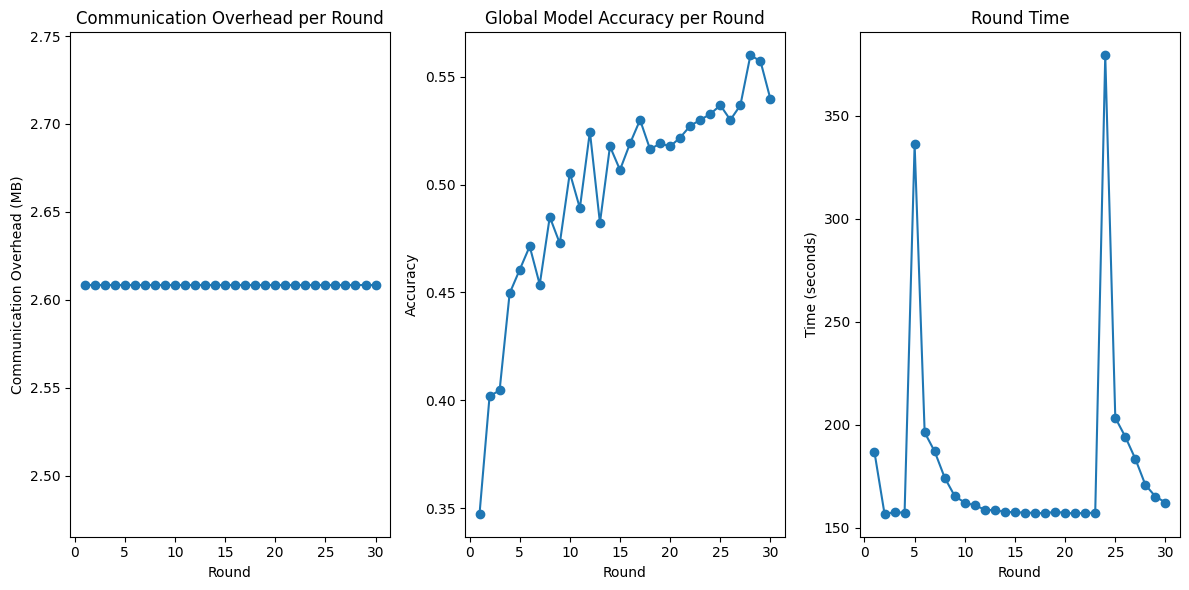

In [ ]:

# Define the global CNN model
def create_cnn_model(input_shape, num_classes):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(num_classes, activation='softmax')  # Number of classes for the Flowers dataset
    ])
    return model

# Create federated data by splitting the dataset among clients
def create_federated_data(dataset, num_clients=90):
    client_data = []
    data_per_client = len(dataset) // num_clients
    for i in range(num_clients):
        client_ds = dataset.skip(i * data_per_client).take(data_per_client)
        client_data.append(client_ds)
    return client_data

# Measure communication overhead
def measure_communication_overhead(weights):
    return sum([np.prod(w.shape) for w in weights]) * 4 / (1024 * 1024)  # in MB

# Federated learning parameters
num_clients =90
num_rounds = 30
local_epochs = 3
accuracy_threshold = 0.70  # Define an accuracy threshold for convergence speed

# Load and preprocess data
train_ds, test_ds, ds_info = load_and_preprocess_data()

# Create federated data for each client
federated_train_data = create_federated_data(train_ds, num_clients)

# Create global model
input_shape = (64, 64, 3)  # Input shape for the Flowers dataset
num_classes = ds_info.features['label'].num_classes
global_model = create_cnn_model(input_shape, num_classes)
global_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Initialize variables to measure communication overhead and convergence speed
total_communication_overhead = 0
convergence_round = None
start_time = time.time()

# Lists to store metrics for visualization
communication_overheads = []
accuracies = []
round_times = []

# Federated learning loop
for round_num in range(num_rounds):
    print(f"Round {round_num + 1}/{num_rounds}")

    local_weights = []
    round_start_time = time.time()

    # Train on each client
    for client_id in range(num_clients):
        print(f"Training on client {client_id + 1}")

        # Create local model and set global weights
        local_model = create_cnn_model(input_shape, num_classes)
        local_model.set_weights(global_model.get_weights())
        local_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

        # Get client data
        client_ds = federated_train_data[client_id]

        # Train local model
        local_model.fit(client_ds, epochs=local_epochs,batch_size=32, verbose=0)

        # Collect local model weights
        local_weights.append(local_model.get_weights())

    # Federated averaging: Aggregate local weights
    averaged_weights = [np.mean([local_weights[j][i] for j in range(num_clients)], axis=0)
                        for i in range(len(local_weights[0]))]

    # Measure communication overhead
    round_communication_overhead = measure_communication_overhead(averaged_weights)
    total_communication_overhead += round_communication_overhead
    communication_overheads.append(round_communication_overhead)
    print(f"Communication overhead for round {round_num + 1}: {round_communication_overhead:.4f} MB")

    # Update global model weights
    global_model.set_weights(averaged_weights)

    # Evaluate the global model
    loss, accuracy = global_model.evaluate(test_ds, verbose=0)
    accuracies.append(accuracy)
    print(f"Global model accuracy after round {round_num + 1}: {accuracy:.4f}")

    # Check for convergence
    if convergence_round is None and accuracy >= accuracy_threshold:
        convergence_round = round_num + 1
        convergence_time = time.time() - start_time
        print(f"Convergence achieved at round {convergence_round} with accuracy {accuracy:.4f}")
        print(f"Convergence time: {convergence_time:.2f} seconds")

    # Record round time
    round_time = time.time() - round_start_time
    round_times.append(round_time)

# Evaluate the final global model
final_loss, final_accuracy = global_model.evaluate(test_ds, verbose=0)
print(f"Final global model accuracy: {final_accuracy:.4f}")

# Print total communication overhead
print(f"Total communication overhead: {total_communication_overhead:.4f} MB")

# Print convergence information if not already printed
if convergence_round is None:
    convergence_time = time.time() - start_time
    print(f"Convergence not achieved within {num_rounds} rounds.")
else:
    print(f"Convergence achieved at round {convergence_round} with accuracy {final_accuracy:.4f}")
    print(f"Convergence time: {convergence_time:.2f} seconds")

# Visualization
rounds = list(range(1, num_rounds + 1))

plt.figure(figsize=(12, 6))

# Plot communication overhead
plt.subplot(1, 3, 1)
plt.plot(rounds, communication_overheads, marker='o')
plt.title('Communication Overhead per Round')
plt.xlabel('Round')
plt.ylabel('Communication Overhead (MB)')

# Plot accuracy
plt.subplot(1, 3, 2)
plt.plot(rounds, accuracies, marker='o')
plt.title('Global Model Accuracy per Round')
plt.xlabel('Round')
plt.ylabel('Accuracy')

# Plot round times
plt.subplot(1, 3, 3)
plt.plot(rounds, round_times, marker='o')
plt.title('Round Time')
plt.xlabel('Round')
plt.ylabel('Time (seconds)')

plt.tight_layout()
plt.show()

**EXPERIMENT TEN**

Training data shape: 2936
Testing data shape: 734
Round 1/30
Training on client 1
Training on client 2
Training on client 3
Training on client 4
Training on client 5
Training on client 6
Training on client 7
Training on client 8
Training on client 9
Training on client 10
Training on client 11
Training on client 12
Training on client 13
Training on client 14
Training on client 15
Training on client 16
Training on client 17
Training on client 18
Training on client 19
Training on client 20
Training on client 21
Training on client 22
Training on client 23
Training on client 24
Training on client 25
Training on client 26
Training on client 27
Training on client 28
Training on client 29
Training on client 30
Training on client 31
Training on client 32
Training on client 33
Training on client 34
Training on client 35
Training on client 36
Training on client 37
Training on client 38
Training on client 39
Training on client 40
Training on client 41
Training on client 42
Training on client 43
Tr

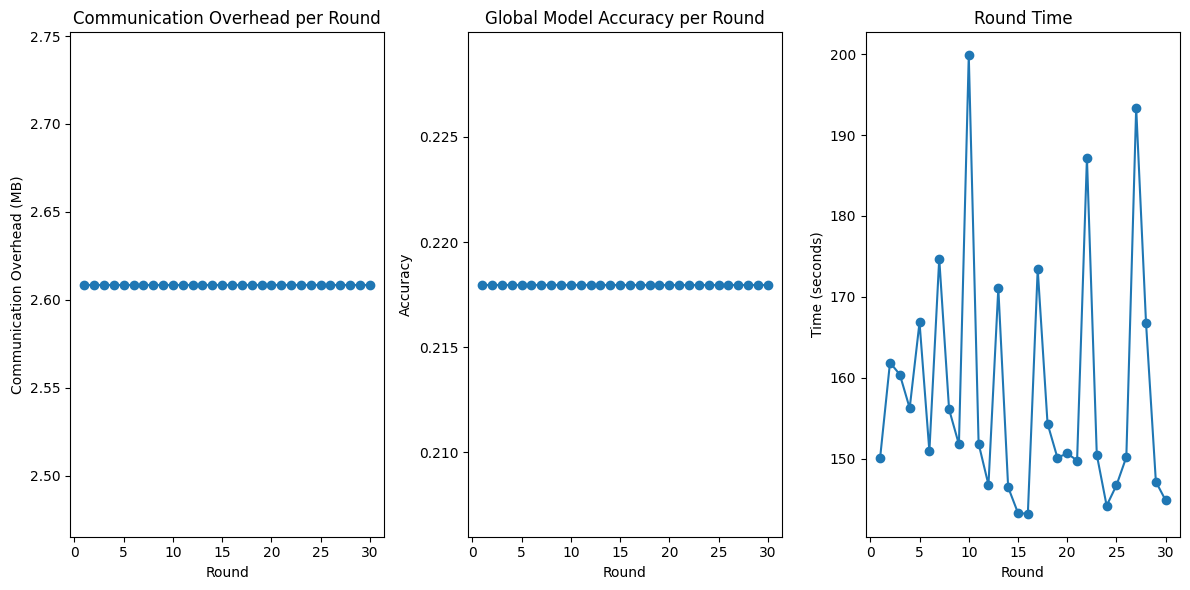

In [ ]:

# Define the global CNN model
def create_cnn_model(input_shape, num_classes):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(num_classes, activation='softmax')  # Number of classes for the Flowers dataset
    ])
    return model

# Create federated data by splitting the dataset among clients
def create_federated_data(dataset, num_clients=100):
    client_data = []
    data_per_client = len(dataset) // num_clients
    for i in range(num_clients):
        client_ds = dataset.skip(i * data_per_client).take(data_per_client)
        client_data.append(client_ds)
    return client_data

# Measure communication overhead
def measure_communication_overhead(weights):
    return sum([np.prod(w.shape) for w in weights]) * 4 / (1024 * 1024)  # in MB

# Federated learning parameters
num_clients =100
num_rounds = 30
local_epochs = 3
accuracy_threshold = 0.70  # Define an accuracy threshold for convergence speed

# Load and preprocess data
train_ds, test_ds, ds_info = load_and_preprocess_data()

# Create federated data for each client
federated_train_data = create_federated_data(train_ds, num_clients)

# Create global model
input_shape = (64, 64, 3)  # Input shape for the Flowers dataset
num_classes = ds_info.features['label'].num_classes
global_model = create_cnn_model(input_shape, num_classes)
global_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Initialize variables to measure communication overhead and convergence speed
total_communication_overhead = 0
convergence_round = None
start_time = time.time()

# Lists to store metrics for visualization
communication_overheads = []
accuracies = []
round_times = []

# Federated learning loop
for round_num in range(num_rounds):
    print(f"Round {round_num + 1}/{num_rounds}")

    local_weights = []
    round_start_time = time.time()

    # Train on each client
    for client_id in range(num_clients):
        print(f"Training on client {client_id + 1}")

        # Create local model and set global weights
        local_model = create_cnn_model(input_shape, num_classes)
        local_model.set_weights(global_model.get_weights())
        local_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

        # Get client data
        client_ds = federated_train_data[client_id]

        # Train local model
        local_model.fit(client_ds, epochs=local_epochs,batch_size=32, verbose=0)

        # Collect local model weights
        local_weights.append(local_model.get_weights())

    # Federated averaging: Aggregate local weights
    averaged_weights = [np.mean([local_weights[j][i] for j in range(num_clients)], axis=0)
                        for i in range(len(local_weights[0]))]

    # Measure communication overhead
    round_communication_overhead = measure_communication_overhead(averaged_weights)
    total_communication_overhead += round_communication_overhead
    communication_overheads.append(round_communication_overhead)
    print(f"Communication overhead for round {round_num + 1}: {round_communication_overhead:.4f} MB")

    # Update global model weights
    global_model.set_weights(averaged_weights)

    # Evaluate the global model
    loss, accuracy = global_model.evaluate(test_ds, verbose=0)
    accuracies.append(accuracy)
    print(f"Global model accuracy after round {round_num + 1}: {accuracy:.4f}")

    # Check for convergence
    if convergence_round is None and accuracy >= accuracy_threshold:
        convergence_round = round_num + 1
        convergence_time = time.time() - start_time
        print(f"Convergence achieved at round {convergence_round} with accuracy {accuracy:.4f}")
        print(f"Convergence time: {convergence_time:.2f} seconds")

    # Record round time
    round_time = time.time() - round_start_time
    round_times.append(round_time)

# Evaluate the final global model
final_loss, final_accuracy = global_model.evaluate(test_ds, verbose=0)
print(f"Final global model accuracy: {final_accuracy:.4f}")

# Print total communication overhead
print(f"Total communication overhead: {total_communication_overhead:.4f} MB")

# Print convergence information if not already printed
if convergence_round is None:
    convergence_time = time.time() - start_time
    print(f"Convergence not achieved within {num_rounds} rounds.")
else:
    print(f"Convergence achieved at round {convergence_round} with accuracy {final_accuracy:.4f}")
    print(f"Convergence time: {convergence_time:.2f} seconds")

# Visualization
rounds = list(range(1, num_rounds + 1))

plt.figure(figsize=(12, 6))

# Plot communication overhead
plt.subplot(1, 3, 1)
plt.plot(rounds, communication_overheads, marker='o')
plt.title('Communication Overhead per Round')
plt.xlabel('Round')
plt.ylabel('Communication Overhead (MB)')

# Plot accuracy
plt.subplot(1, 3, 2)
plt.plot(rounds, accuracies, marker='o')
plt.title('Global Model Accuracy per Round')
plt.xlabel('Round')
plt.ylabel('Accuracy')

# Plot round times
plt.subplot(1, 3, 3)
plt.plot(rounds, round_times, marker='o')
plt.title('Round Time')
plt.xlabel('Round')
plt.ylabel('Time (seconds)')

plt.tight_layout()
plt.show()

**CENTRALIZED EXPERIMENT**

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/tf_flowers/incomplete.2YDPTJ_3.0.1/tf_flowers-train.tfrecord*...:   0%|   …

Dataset tf_flowers downloaded and prepared to /root/tensorflow_datasets/tf_flowers/3.0.1. Subsequent calls will reuse this data.
Training data shape: 2936
Testing data shape: 734
Epoch 1/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 57ms/step - accuracy: 0.3746 - loss: 1.4121 - val_accuracy: 0.5681 - val_loss: 1.0583
Epoch 2/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5650 - loss: 1.0685 - val_accuracy: 0.6199 - val_loss: 0.9655
Epoch 3/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6413 - loss: 0.9089 - val_accuracy: 0.6608 - val_loss: 0.8762
Epoch 4/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6768 - loss: 0.8155 - val_accuracy: 0.6703 - val_loss: 0.8610
Epoch 5/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6974 - loss: 0.7574 - val_accuracy: 0.6771 - val_loss: 0.8181
Epoch 6/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7565 - loss: 0.6248 - val_accuracy: 0.6948 - val_loss: 0.7647
Epoch 7/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0

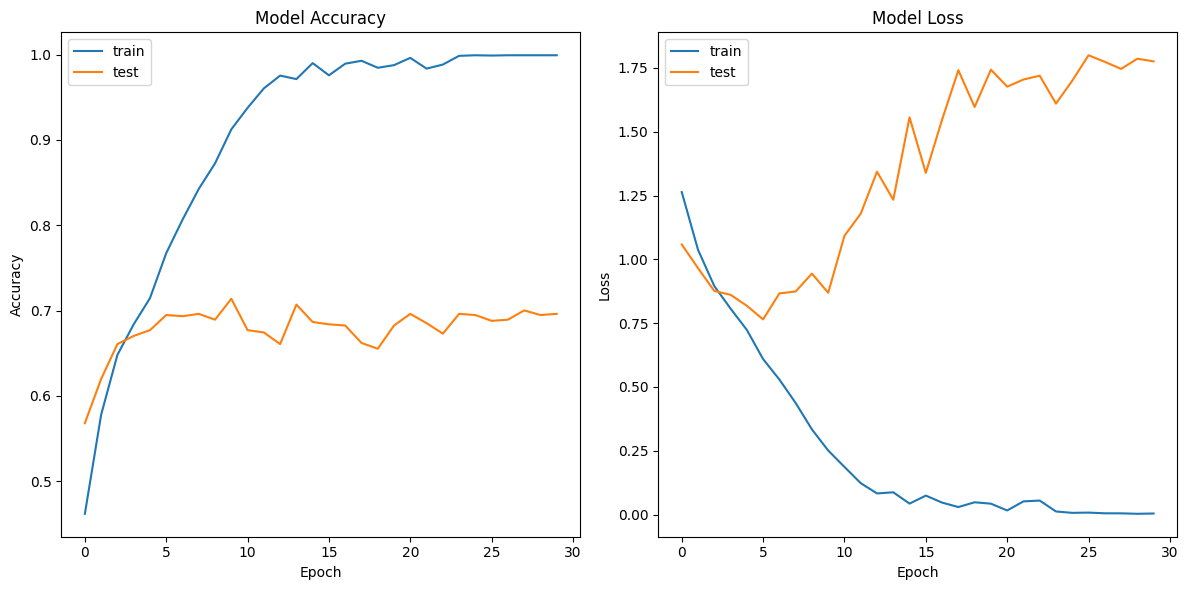

In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import time
import matplotlib.pyplot as plt

# Load and preprocess the Flowers dataset
def load_and_preprocess_data():
    # Load the dataset
    (train_ds, test_ds), ds_info = tfds.load(
        'tf_flowers',
        split=['train[:80%]', 'train[80%:]'],
        with_info=True,
        as_supervised=True
    )

    # Define image size and batch size
    img_size = (64, 64)
    batch_size = 32

    # Preprocess the dataset
    def preprocess(image, label):
        image = tf.image.resize(image, img_size)
        image = tf.cast(image, tf.float32) / 255.0
        return image, label

    train_ds = train_ds.map(preprocess).shuffle(buffer_size=1000).batch(batch_size).prefetch(tf.data.experimental.AUTOTUNE)
    test_ds = test_ds.map(preprocess).batch(batch_size).prefetch(tf.data.experimental.AUTOTUNE)

    # Print shapes of the datasets
    print(f"Training data shape: {ds_info.splits['train[:80%]'].num_examples}")
    print(f"Testing data shape: {ds_info.splits['train[80%:]'].num_examples}")

    return train_ds, test_ds, ds_info

# Define the global CNN model
def create_cnn_model(input_shape, num_classes):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(num_classes, activation='softmax')  # Number of classes for the Flowers dataset
    ])
    return model

# Load and preprocess data
train_ds, test_ds, ds_info = load_and_preprocess_data()

# Create and compile the model
input_shape = (64, 64, 3)  # Input shape for the Flowers dataset
num_classes = ds_info.features['label'].num_classes
model = create_cnn_model(input_shape, num_classes)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
start_time = time.time()
history = model.fit(train_ds, epochs=30, validation_data=test_ds, verbose=1)
training_time = time.time() - start_time

# Evaluate the model
final_loss, final_accuracy = model.evaluate(test_ds, verbose=0)
print(f"Final model accuracy: {final_accuracy:.4f}")
print(f"Training time: {training_time:.2f} seconds")

# Visualization
plt.figure(figsize=(12, 6))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='test')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()